<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/Gabriel_Tayo_Owolabi_diabetes_knn_complete_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Diagnosis System using KNN

## Author: Gabriel Owolabi

## Objective
This notebook implements a K-Nearest Neighbors (KNN) classifier to predict diabetes using the Pima Indians dataset. The study investigates the trade-off between precision and recall and evaluates three models:

- Model A: High Recall (minimize false negatives)
- Model B: High Precision (minimize false positives)
- Model C: Optimized F1 Score (balance between precision and recall)

---

## 1. Import Libraries

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset
Ensure the file `diabetes.csv` is in the same directory.

In [13]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Data Preprocessing

### Handling Invalid Values
Certain medical measurements cannot be zero. These values are replaced with NaN and imputed using the median.

In [14]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

### Feature Scaling
KNN is distance-based, so normalization is essential.

In [6]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## 4. Evaluation Function

In [7]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1-score: {f1:.3f}")

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return acc, prec, rec, f1

## 5. Testing Different K Values and Distance Metrics

In [8]:
k_values = range(1, 21)
results = []

for k in k_values:
    for metric in ['euclidean', 'manhattan', 'minkowski']:
        if metric == 'minkowski':
            model = KNeighborsClassifier(n_neighbors=k, metric=metric, p=3)
        else:
            model = KNeighborsClassifier(n_neighbors=k, metric=metric)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            'k': k,
            'metric': metric,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred)
        })

results_df = pd.DataFrame(results)
results_df.head()

,k,metric,accuracy,precision,recall,f1
0,1,euclidean,0.655844,0.517857,0.527273,0.522523
1,1,manhattan,0.681818,0.548387,0.618182,0.581197
2,1,minkowski,0.655844,0.518519,0.509091,0.513761
3,2,euclidean,0.662338,0.548387,0.309091,0.395349
4,2,manhattan,0.675325,0.575758,0.345455,0.431818


## 6. Model A – High Recall

Model A (High Recall)
Accuracy: 0.701
Precision: 0.579
Recall: 0.600
F1-score: 0.589


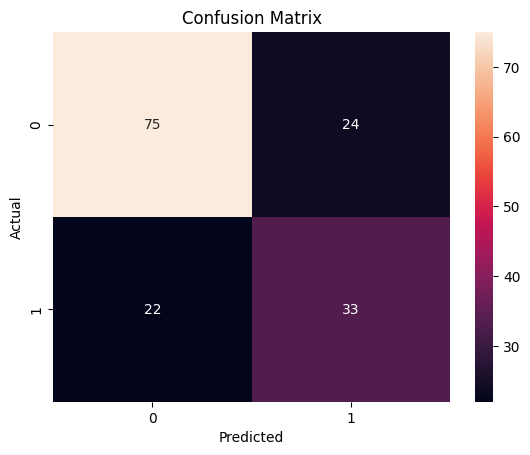

(0.7012987012987013, 0.5789473684210527, 0.6, 0.5892857142857143)

In [15]:
model_A = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
model_A.fit(X_train, y_train)

print('Model A (High Recall)')
evaluate_model(model_A, X_test, y_test)

## 7. Model B – High Precision

Model B (High Precision)
Accuracy: 0.740
Precision: 0.647
Recall: 0.600
F1-score: 0.623


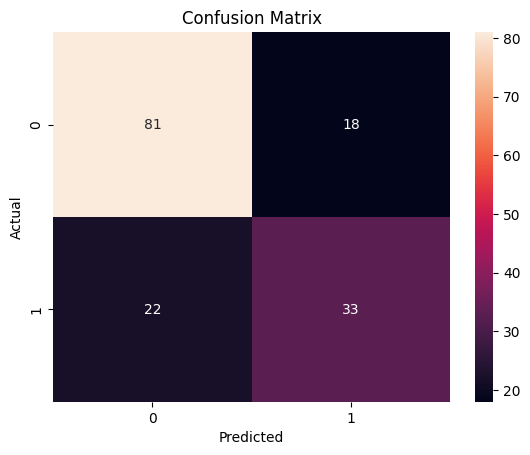

(0.7402597402597403, 0.6470588235294118, 0.6, 0.6226415094339622)

In [16]:
model_B = KNeighborsClassifier(n_neighbors=15, metric='euclidean')
model_B.fit(X_train, y_train)

print('Model B (High Precision)')
evaluate_model(model_B, X_test, y_test)

## 8. Model C – Best F1 Score

k                   13
metric       euclidean
accuracy       0.75974
precision     0.666667
recall        0.654545
f1             0.66055
Name: 36, dtype: object
Model C (Best F1 Score)
Accuracy: 0.760
Precision: 0.667
Recall: 0.655
F1-score: 0.661


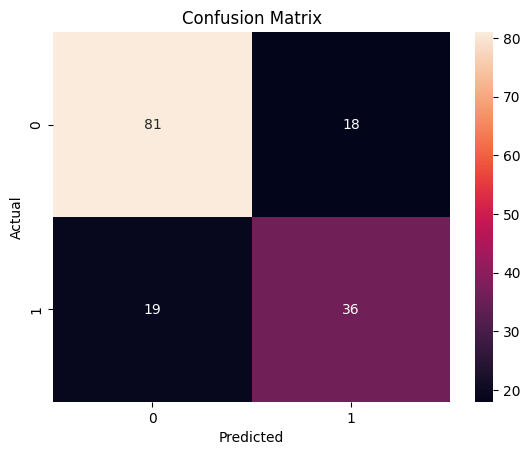

(0.7597402597402597,
 0.6666666666666666,
 0.6545454545454545,
 0.6605504587155964)

In [17]:
best_model = results_df.loc[results_df['f1'].idxmax()]
print(best_model)

model_C = KNeighborsClassifier(
    n_neighbors=int(best_model['k']),
    metric=best_model['metric']
)

model_C.fit(X_train, y_train)

print('Model C (Best F1 Score)')
evaluate_model(model_C, X_test, y_test)

## 9. Critical Analysis

### Precision vs Recall
- Recall measures the ability to detect diabetic patients.
- Precision measures how many predicted diabetics are actually diabetic.

### Medical Implications
- False Negative: A sick patient is not diagnosed → highly dangerous.
- False Positive: A healthy patient is diagnosed → unnecessary tests and anxiety.

### Conclusion
In medical diagnosis, recall is more important than precision because missing a sick patient can have severe consequences.

While F1-score provides a balance, prioritizing recall is often preferred in healthcare applications.

### Distance Metrics
- Euclidean: Sensitive to scale
- Manhattan: More robust to outliers
- Minkowski: Generalized distance

Manhattan distance often performs better for structured medical datasets.
